### Implementing the Backward Propagation from Scratch

In [3]:
import math 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 8*x + 5

f(3.0)

8.0

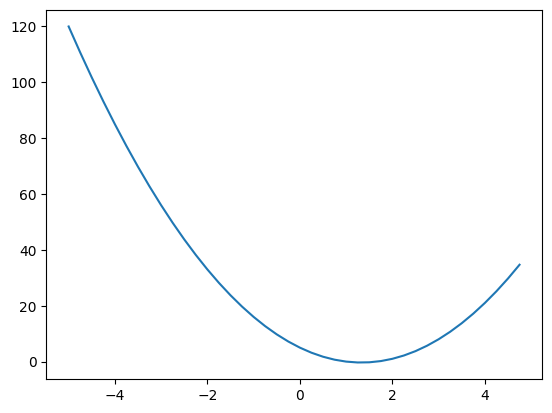

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys);

### Concept of differentiation

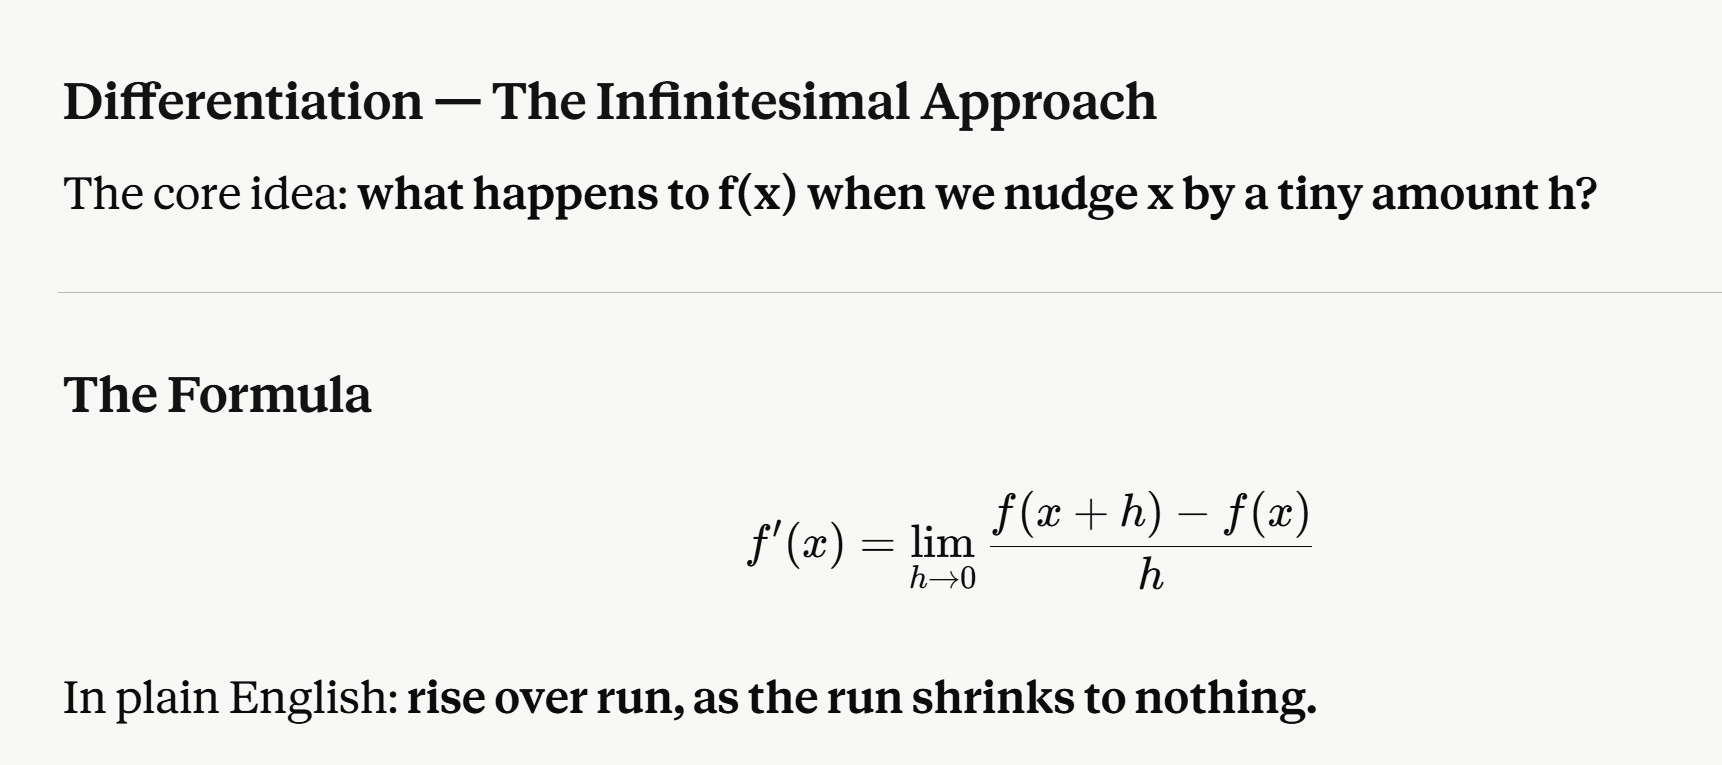

In [6]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

-3.99999700029241

In [7]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [10]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [11]:
def derivative(f, x, h=1e-7):
    return (f(x + h) - f(x)) / h

In [12]:
f = lambda x: x**2  
print(derivative(f, x=2))

4.000000091153311


In [13]:
df = lambda x: 2 * x  
print(derivative(f, -1))

-1.999999899027216


In [15]:
def partial_derivative(f, a, b, c, variable="a", h=1e-7):
    if variable == "a":
        return (f(a + h, b, c) - f(a, b, c)) / h
    elif variable == "b":
        return (f(a, b + h, c) - f(a, b, c)) / h
    elif variable == "c":
        return (f(a, b, c + h) - f(a, b, c)) / h
    else:
        raise ValueError("variable must be 'a', 'b', or 'c'")


def f(a, b, c):
    return 2 * a + b * c


# Example
print(partial_derivative(f, 2, 3, 4, variable="a"))  # ≈ 2
print(partial_derivative(f, 2, 3, 4, variable="b"))  # ≈ 4
print(partial_derivative(f, 2, 3, 4, variable="c"))  # ≈ 3

1.999999987845058
3.999999975690116
2.9999999995311555


In [17]:
def derivative(f, x, var=0, h=1e-7):
    """
    Numerical partial derivative of f with respect to x[var].

    Parameters
    ----------
    f : callable
        Function of any number of variables.
    x : list or tuple
        Input values.
    var : int
        Index of the variable to differentiate.
    h : float
        Small step.

    Returns
    -------
    float
    """
    x = list(x)

    x_forward = x.copy()
    x_forward[var] += h

    return (f(*x_forward) - f(*x)) / h

In [18]:
def f(a, b, c):
    return 2*a + b*c

x = [2, 3, 4]

print(derivative(f, x, var=0))   # ∂f/∂a ≈ 2
print(derivative(f, x, var=1))   # ∂f/∂b ≈ 4
print(derivative(f, x, var=2))   # ∂f/∂c ≈ 3

1.999999987845058
3.999999975690116
2.9999999995311555


In [19]:
def g(a, b, c, d, e):
    return a**2 + b*c - d/e + a*b*c

x = [1, 2, 3, 4, 5]

print(derivative(g, x, var=3))   # derivative w.r.t. d

-0.1999999810209374


In [ ]:
import numpy as np 
import math

class Tensor:
    def __init__(self, data, _children=(), _op="", requires_grad=True):
        self._data = np.asarray(data, dtype=np.float16)
        self.grad = np.zeros_like(self.data)
        self.requires_grad = requires_grad
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op  # for debugging / graph visualization
    
    @property 
    def ndim(self):
        return self._data.shape 
    
    @property
    def data(self):
        return self._data.tolist()
    
    @property
    def shape(self):
        row, col = len(self.data), len(self.data[0])
    
    @property
    def size(self):
        length = 0
        for i in range(len(self.data)):
            length += len(self.data[i])
        return length
    
    @property
    def dtype(self):



In [21]:
array = np.array([[2, 3, 4], [5, 6, 7]])

length = 0
for i in range(len(array)):
    length += len(array[i])

In [22]:
length

6

In [23]:
np.shape(np.array(5))

()

In [112]:
import numpy as np 
import math

class Tensor:
    def __init__(self, data, requires_grad=True, _children = (), _op = ""):

        if isinstance(data, np.ndarray):
            self._data = data.tolist()      # convert to nested lists
        else:
            self._data = data

        self._validate(self._data)
        self.grad = self._zeros_like(self._data)
        self.requires_grad = requires_grad
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op  # for debugging / graph visualization

    def _zeros_like(self, data):
        if isinstance(data, list):
            return [self._zeros_like(item) for item in data]
        return 0.0

    def __repr__(self):
        return f"Tensor(data={self._data}, grad={self.grad})"

    def _validate(self, data):
        """Ensure that every dimension of the tensor has a constant shape"""
        if not isinstance(data, list):
            return 
        if len(data) == 0:
            return 
        
        first_is_list = isinstance(data[0], list)
        for item in data:
            if isinstance(item, list) != first_is_list:
                raise ValueError(
                    "Invalid tensor: Mixed scalars and list"
                )
            
        if first_is_list:
            for item in data:
                if len(item) != len(data[0]):
                    raise ValueError(
                        "Invalid tensor: inconsistent dimension"
                    )
                self._validate(item)
    
    @property 
    def ndim(self):
        return len(self.shape)
    
    @property
    def data(self):
        return self._data
    
    @property
    def shape(self):
        shape_ = []
        current = self._data
        while isinstance(current, list):
            record = len(current)
            shape_.append(record)
            if record == 0:
                break              
            current = current[0]
        return tuple(shape_)

    
    @property
    def size(self):
        return self._size(self._data)

    def _size(self, data):
        if not isinstance(data, list):
            return 1
        total = 0
        for item in data:
            total += self._size(item)

        return total

    def _add_recursive(self, a, b):
        if isinstance(a, list):
            return [self._add_recursive(x, y) for x, y in zip(a, b)]
        return a + b
    
    def _subtract_recursive(self, a, b):
        if isinstance(a, list):
            return [self._subtract_recursive(x, y) for x, y in zip(a, b)]
        return a - b
    
    def _negate_recursive(self, a):
        if isinstance(a, list):
            return [self._negate_recursive(x) for x in a]
        return -a

    def __sub__(self, other):
        assert self.shape == other.shape, \
            f"Shape mismatch: {self.shape} vs {other.shape}"

        out = Tensor(
            self._subtract_recursive(self._data, other._data),
            requires_grad=self.requires_grad or other.requires_grad,
            _children=(self, other),
            _op="-"
        )

        def _backward():
            if self.requires_grad:
                self.grad = self._add_recursive(self.grad, out.grad)
            if other.requires_grad:                                        # b gets negated gradient
                other.grad = self._add_recursive(other.grad, self._negate_recursive(out.grad))

        out._backward = _backward
        return out

    def __add__(self, other):
        assert self.shape == other.shape, \
            f"Shape mismatch: {self.shape} vs {other.shape}"

        out = Tensor(
            self._add_recursive(self._data, other._data),
            requires_grad=self.requires_grad or other.requires_grad,
            _children=(self, other),
            _op="+"
        )

        def _backward():
            if self.requires_grad:
                self.grad = self._add_recursive(self.grad, out.grad)
            if other.requires_grad:
                other.grad = self._add_recursive(other.grad, out.grad)

        out._backward = _backward
        return out
    
    def _ones_like(self, data):
        if isinstance(data, list):
            return [self._ones_like(item) for item in data]
        return 1.0

    def _multiply_recursive(self, a, b):  # fix: was `elf` not `self`
        if isinstance(a, list):
            return [self._multiply_recursive(x, y) for x, y in zip(a, b)]
        return a * b

    def __mul__(self, other):
        assert self.shape == other.shape, \
            f"Shape mismatch: {self.shape} vs {other.shape}"

        out = Tensor(
            self._multiply_recursive(self._data, other._data),
            requires_grad=self.requires_grad or other.requires_grad,
            _children=(self, other),
            _op="*"
        )

        def _backward():
            if self.requires_grad:                                        # scale by b
                self.grad = self._add_recursive(self.grad, self._multiply_recursive(out.grad, other._data))
            if other.requires_grad:                                       # scale by a
                other.grad = self._add_recursive(other.grad, self._multiply_recursive(out.grad, self._data))

        out._backward = _backward
        return out
        
    def backward(self):
        # seed the gradient
        self.grad = self._ones_like(self._data)

        # build topological order
        topo = []
        visited = set()
        def build_topo(node):
            if id(node) not in visited:
                visited.add(id(node))
                for child in node._prev:
                    build_topo(child)
                topo.append(node)

        build_topo(self)

        # backprop in reverse
        for node in reversed(topo):
            node._backward()

In [113]:
Tensor([[1,2],[3,4], [5, 4]]).shape

(3, 2)

In [114]:
Tensor([[1,2],[3,4], [5, 4]]).ndim

2

In [115]:
Tensor([[1,2],[3,4], [5, 4]]).data

[[1, 2], [3, 4], [5, 4]]

In [116]:
Tensor(5).shape

()

In [117]:
Tensor(5).ndim

0

In [118]:
a = Tensor([[1, 2], [3, 4], [5, 6]])
b = Tensor([[0, 1], [2, 1], [0, 2]])

a + b

Tensor(data=[[1, 3], [5, 5], [5, 8]], grad=[[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]])

In [119]:
a

Tensor(data=[[1, 2], [3, 4], [5, 6]], grad=[[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]])

In [120]:
a.grad

[[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]

In [121]:
a = Tensor([[1.0, 2.0]])
b = Tensor([[3.0, 4.0]])
c = Tensor([[5.0, 7.0]])

L = (a + b) + c
L.backward()  # walks the full graph automatically

print(a.grad)  # [[1.0, 1.0]] ✓
print(b.grad)  # [[1.0, 1.0]] ✓
print(c.grad)  # [[1.0, 1.0]] ✓

[[1.0, 1.0]]
[[1.0, 1.0]]
[[1.0, 1.0]]


In [122]:
a = Tensor([[1.0, 2.0]])
b = Tensor([[3.0, 4.0]])
c = Tensor([[5.0, 7.0]])

L = (a + b) - c
L.backward()  # walks the full graph automatically

print(a.grad)  # [[1.0, 1.0]] ✓
print(b.grad)  # [[1.0, 1.0]] ✓
print(c.grad)  # [[1.0, 1.0]] ✓

[[1.0, 1.0]]
[[1.0, 1.0]]
[[-1.0, -1.0]]


In [123]:
a = Tensor([[1.0, 2.0]])
b = Tensor([[3.0, 4.0]])
c = Tensor([[5.0, 7.0]])

L = (a * b) - c
L.backward()  # walks the full graph automatically

print(a.grad)  # [[1.0, 1.0]] ✓
print(b.grad)  # [[1.0, 1.0]] ✓
print(c.grad)  # [[1.0, 1.0]] ✓

[[3.0, 4.0]]
[[1.0, 2.0]]
[[-1.0, -1.0]]
